# Ataque Black Hole Repeater

Este notebook tem o objetivo de demonstrar um ataque Black Hole Repeater em uma rede quântica simulada.

Esse ataque ocorre de forma silenciosa. O nó malicioso não altera a topologia, não muda fidelidade e não recusa conexões. Ele apenas sabota a própria operação de entanglement swapping, forçando uma probabilidade de falha maior do que o normal.

A demosntração desse ataque considera a topologia a seguir:
```
Nó A (0) ──── R1 (1) ──── R2 (2) ──── Nó B (3)
```

Toda requisição de entrelaçamento fim a fim entre A e B passa obrigatoriamente pelos repetidores R1 e R2, que realizam entanglement swapping.

No simulador, a probabilidade de sucesso do swap é `P_swap = f1 × f2`, produto das fidelidades dos dois pares EPR consumidos. O ataque consiste em reduzir essa probabilidade no nó malicioso:

```
P_swap_efetiva = max(P_swap − attack_intensity, 0)
```

### Sumário
1. Configuração e cenário base
2. Injeção do comportamento malicioso
3. Comparação: rede íntegra vs. rede comprometida
4. Varredura da intensidade do ataque
5. Log detalhado de eventos de swap

## 1. Configuração e Imports

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import random
import numpy as np
import matplotlib.pyplot as plt
from random import uniform

from quantumnet.runtime import Clock
from quantumnet.topology.network import Network

## 2. Monkey-Patch para Interceptar o Swap

O método `NetworkLayer._do_one_swap` calcula `success_prob = f1 × f2` e rola um número aleatório. Vamos **substituí-lo** por uma versão que verifica se o nó intermediário (o nó que realiza a BSM) está marcado como `is_malicious` no grafo. Se estiver, a probabilidade é reduzida pela `attack_intensity` configurada naquele nó.

In [ ]:
from quantumnet.layers.network_layer import NetworkLayer
from quantumnet.quantum import Epr

# Guardar referência ao método original
_original_do_one_swap = NetworkLayer._do_one_swap

def _patched_do_one_swap(self, route, alice, bob, on_complete):
    """Versão instrumentada de _do_one_swap que aplica penalidade de swap em nós maliciosos."""
    self.logger.log(f'Timeslot {self._context.clock.now}: Performing Entanglement Swapping.')

    node1 = route[0]
    node2 = route[1]        # nó que realiza o swap (BSM)
    node3 = route[2] if len(route) > 2 else None

    if not self._context.graph.has_edge(node1, node2):
        self.logger.log(f'Channel between {node1}-{node2} does not exist')
        if on_complete is not None:
            on_complete(success=False)
        return

    eprs_edge1 = self._context.get_eprs_from_edge(node1, node2)
    if not eprs_edge1:
        self.logger.log(f'Not enough EPR pairs between {node1}-{node2}')
        if on_complete is not None:
            on_complete(success=False)
        return
    epr1 = max(eprs_edge1, key=lambda e: e.current_fidelity)

    if node3 is not None:
        if not self._context.graph.has_edge(node2, node3):
            self.logger.log(f'Channel between {node2}-{node3} does not exist')
            if on_complete is not None:
                on_complete(success=False)
            return

        eprs_edge2 = self._context.get_eprs_from_edge(node2, node3)
        if not eprs_edge2:
            self.logger.log(f'Not enough EPR pairs between {node2}-{node3}')
            if on_complete is not None:
                on_complete(success=False)
            return
        epr2 = max(eprs_edge2, key=lambda e: e.current_fidelity)

        fidelity1 = epr1.current_fidelity
        fidelity2 = epr2.current_fidelity

        success_prob = fidelity1 * fidelity2

        #### INTERCEPTAÇÃO - COMPORTAMENTO MALICIOSO #####
        node_data = self._context.graph.nodes[node2]
        if node_data.get('is_malicious', False):
            intensity = node_data.get('attack_intensity', 0.0)
            success_prob = max(success_prob - intensity, 0.0)
        ##################################################

        if uniform(0, 1) > success_prob:
            self.logger.log(f'Entanglement Swapping failed between {node1}-{node2} and {node2}-{node3}')
            if on_complete is not None:
                on_complete(success=False)
            return

        new_fidelity = fidelity1 * fidelity2
        epr_virtual = Epr(
            (node1, node3), new_fidelity,
            clock=self._context.clock,
            decoherence_rate=self._context.config.decoherence.per_timeslot
        )

        if not self._context.graph.has_edge(node1, node3):
            self._context.graph.add_edge(node1, node3, eprs=[])

        self._physical_layer.add_epr_to_channel(epr_virtual, (node1, node3))
        self._physical_layer.remove_epr_from_channel(epr1, (node1, node2))
        self._physical_layer.remove_epr_from_channel(epr2, (node2, node3))

        self.logger.log(f'{self.__class__.__name__}: 1 EPR used')

        route.pop(1)
    else:
        route.pop(1)

    self._swap_next(route, alice, bob, on_complete)

# Aplicar o patch
NetworkLayer._do_one_swap = _patched_do_one_swap
print('Patch aplicado com sucesso.')

Patch aplicado com sucesso.


## 3. Funções Auxiliares

In [ ]:
def criar_rede(eprs_por_canal=10):
    """Cria uma rede em linha com 4 nós: A(0) - R1(1) - R2(2) - B(3)."""
    clk = Clock()
    net = Network(clock=clk)
    net.config.defaults.eprs_per_channel = eprs_por_canal
    net.config.decoherence.per_timeslot = 1.0   # desativar decoerência para isolar o efeito do ataque
    net.config.decoherence.per_measurement = 1.0
    net.set_ready_topology('Line', 4)            # nós 0, 1, 2, 3
    return clk, net


def marcar_malicioso(net, node_id, attack_intensity):
    """Marca um nó como malicioso com a intensidade de ataque dada."""
    net.graph.nodes[node_id]['is_malicious'] = True
    net.graph.nodes[node_id]['attack_intensity'] = attack_intensity


def limpar_malicioso(net, node_id):
    """Remove a flag de malicioso de um nó."""
    net.graph.nodes[node_id]['is_malicious'] = False
    net.graph.nodes[node_id]['attack_intensity'] = 0.0


def executar_lote(num_requisicoes, eprs_por_canal=10, malicioso_id=None, attack_intensity=0.0):
    """
    Executa um lote de requisições de entrelaçamento fim a fim (0 -> 3).
    Cada requisição usa uma rede fresca para evitar esgotamento de EPRs.
    
    Retorna: (num_sucesso, num_falha, lista_de_resultados)
    """
    resultados = []
    
    for i in range(num_requisicoes):
        clk, net = criar_rede(eprs_por_canal)
        
        if malicioso_id is not None:
            marcar_malicioso(net, malicioso_id, attack_intensity)
        
        resultado = {}
        def cb(success, r=resultado):
            r['success'] = success
        
        net.networklayer.request_entanglement(0, 3, on_complete=cb)
        clk.run()
        
        resultados.append(resultado.get('success', False))
    
    sucessos = sum(1 for r in resultados if r)
    falhas = num_requisicoes - sucessos
    return sucessos, falhas, resultados

## 4. Cenário Base: Rede Íntegra

Executamos um lote de requisições com todos os repetidores operando normalmente.

In [ ]:
random.seed(42)
NUM_REQUISICOES = 200

print('=== CENÁRIO BASE: Rede Íntegra ===')
print(f'Topologia: A(0) ── R1(1) ── R2(2) ── B(3)')
print(f'Requisições: {NUM_REQUISICOES}')
print()

suc_base, fal_base, _ = executar_lote(NUM_REQUISICOES)
taxa_base = suc_base / NUM_REQUISICOES * 100

print(f'  Sucessos: {suc_base}')
print(f'  Falhas:   {fal_base}')
print(f'  Taxa de sucesso: {taxa_base:.1f}%')

=== CENÁRIO BASE: Rede Íntegra ===
Topologia: A(0) ── R1(1) ── R2(2) ── B(3)
Requisições: 200

  Sucessos: 200
  Falhas:   0
  Taxa de sucesso: 100.0%


## 5. Cenário de Ataque: R2 Malicioso

Ativamos a flag `is_malicious` no repetidor R2 (nó 2) com intensidade de ataque `0.4`. Isso significa que a probabilidade de sucesso do swap realizado por R2 é reduzida em 0.4.

In [ ]:
random.seed(42)
ATTACK_INTENSITY = 0.4
MALICIOUS_NODE = 2  # R2

print(f'=== CENÁRIO DE ATAQUE: R2 (nó {MALICIOUS_NODE}) Malicioso ===')
print(f'Intensidade do ataque: {ATTACK_INTENSITY}')
print(f'Efeito: P_swap = max(f1 × f2 − {ATTACK_INTENSITY}, 0)')
print()

suc_ataque, fal_ataque, _ = executar_lote(
    NUM_REQUISICOES,
    malicioso_id=MALICIOUS_NODE,
    attack_intensity=ATTACK_INTENSITY
)
taxa_ataque = suc_ataque / NUM_REQUISICOES * 100

print(f'  Sucessos: {suc_ataque}')
print(f'  Falhas:   {fal_ataque}')
print(f'  Taxa de sucesso: {taxa_ataque:.1f}%')
print()
print(f'--- Comparação ---')
print(f'  Rede íntegra:      {taxa_base:.1f}%')
print(f'  Rede comprometida: {taxa_ataque:.1f}%')
print(f'  Queda:             {taxa_base - taxa_ataque:.1f} pontos percentuais')

=== CENÁRIO DE ATAQUE: R2 (nó 2) Malicioso ===
Intensidade do ataque: 0.4
Efeito: P_swap = max(f1 × f2 − 0.4, 0)

  Sucessos: 119
  Falhas:   81
  Taxa de sucesso: 59.5%

--- Comparação ---
  Rede íntegra:      100.0%
  Rede comprometida: 59.5%
  Queda:             40.5 pontos percentuais


## 6. Visualização: Rede Íntegra vs. Rede Comprometida

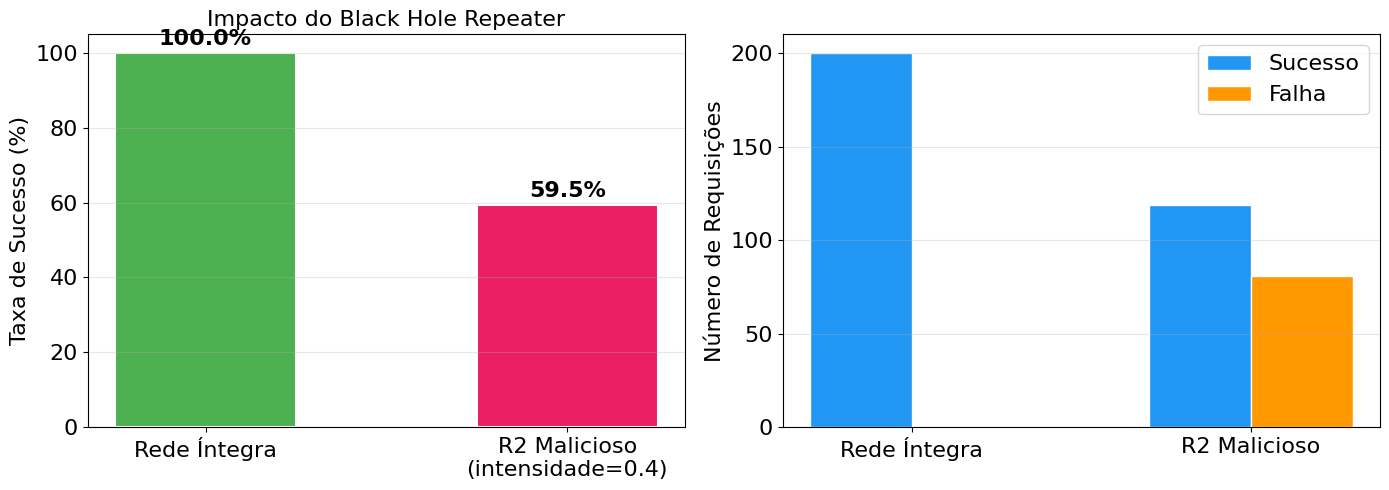

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Barras de comparação ---
categorias = ['Rede Íntegra', f'R2 Malicioso\n(intensidade={ATTACK_INTENSITY})']
taxas = [taxa_base, taxa_ataque]
cores = ['#4CAF50', '#E91E63']

bars = axes[0].bar(categorias, taxas, color=cores, width=0.5, edgecolor='white', linewidth=1.5)
for bar, taxa in zip(bars, taxas):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{taxa:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=16)

axes[0].set_ylabel('Taxa de Sucesso (%)', fontsize=16)
#axes[0].set_title('Impacto do Black Hole Repeater', fontsize=16)
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3, axis='y')

# --- Gráfico 2: Contagem sucesso/falha ---
x = np.arange(2)
width = 0.3

bars_s = axes[1].bar(x - width/2, [suc_base, suc_ataque], width,
                      label='Sucesso', color='#2196F3', edgecolor='white')
bars_f = axes[1].bar(x + width/2, [fal_base, fal_ataque], width,
                      label='Falha', color='#FF9800', edgecolor='white')

axes[1].set_xticks(x)
axes[1].set_xticklabels(['Rede Íntegra', 'R2 Malicioso'], fontsize=16)
axes[1].set_ylabel('Número de Requisições', fontsize=16)
# axes[1].set_title('Sucesso vs. Falha por Cenário', fontsize=16)
axes[1].legend(fontsize=16)
axes[0].tick_params(axis='both', labelsize=16)
axes[1].tick_params(axis='both', labelsize=16)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('img/black_hole_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Varredura da Intensidade do Ataque

Variamos a intensidade do ataque de 0.0 (sem ataque) até 0.9 e observamos como a taxa de sucesso degrada progressivamente.

In [ ]:
random.seed(42)
intensidades = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
taxas_por_intensidade = []

print(f'{"Intensidade":>12} | {"Sucessos":>8} | {"Falhas":>6} | {"Taxa (%)":>8}')
print('-' * 45)

for intensidade in intensidades:
    suc, fal, _ = executar_lote(
        NUM_REQUISICOES,
        malicioso_id=MALICIOUS_NODE,
        attack_intensity=intensidade
    )
    taxa = suc / NUM_REQUISICOES * 100
    taxas_por_intensidade.append(taxa)
    print(f'{intensidade:>12.1f} | {suc:>8} | {fal:>6} | {taxa:>7.1f}%')

 Intensidade | Sucessos | Falhas | Taxa (%)
---------------------------------------------
         0.0 |      200 |      0 |   100.0%
         0.1 |      179 |     21 |    89.5%
         0.2 |      164 |     36 |    82.0%
         0.3 |      143 |     57 |    71.5%
         0.4 |      127 |     73 |    63.5%
         0.5 |      100 |    100 |    50.0%
         0.6 |       88 |    112 |    44.0%
         0.7 |       62 |    138 |    31.0%
         0.8 |       34 |    166 |    17.0%
         0.9 |       18 |    182 |     9.0%


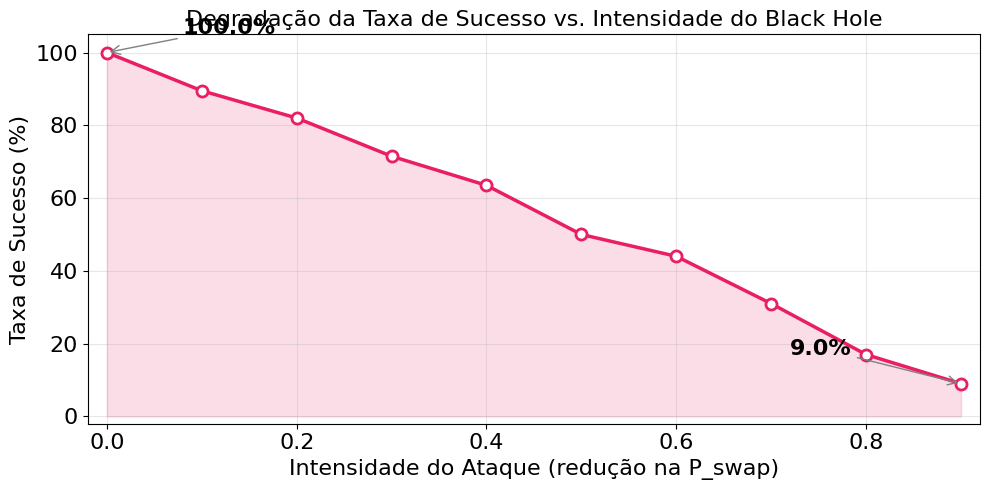

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(intensidades, taxas_por_intensidade, 'o-', color='#E91E63',
        linewidth=2.5, markersize=8, markerfacecolor='white',
        markeredgecolor='#E91E63', markeredgewidth=2)

ax.fill_between(intensidades, taxas_por_intensidade, alpha=0.15, color='#E91E63')

ax.set_xlabel('Intensidade do Ataque (redução na P_swap)', fontsize=16)
ax.set_ylabel('Taxa de Sucesso (%)', fontsize=16)
#ax.set_title('Degradação da Taxa de Sucesso vs. Intensidade do Black Hole', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
ax.set_ylim(-2, 105)
ax.set_xlim(-0.02, 0.92)
ax.grid(True, alpha=0.3)

# Anotar ponto sem ataque e ponto máximo
ax.annotate(f'{taxas_por_intensidade[0]:.1f}%', xy=(0.0, taxas_por_intensidade[0]),
            xytext=(0.08, taxas_por_intensidade[0] + 5), fontsize=16, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate(f'{taxas_por_intensidade[-1]:.1f}%', xy=(0.9, taxas_por_intensidade[-1]),
            xytext=(0.72, taxas_por_intensidade[-1] + 8), fontsize=16, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.savefig('img/black_hole_intensidade.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Log Detalhado: Eventos de Swap

Executamos algumas requisições com e sem ataque, capturando eventos do clock para visualizar como o nó malicioso falha com mais frequência.

In [ ]:
def executar_com_log(num_requisicoes, malicioso_id=None, attack_intensity=0.0):
    """Executa requisições capturando eventos de swap para log detalhado."""
    eventos = []
    
    for i in range(num_requisicoes):
        clk, net = criar_rede(eprs_por_canal=10)
        
        if malicioso_id is not None:
            marcar_malicioso(net, malicioso_id, attack_intensity)
        
        # Capturar eventos de swap
        swap_log = {'req_id': i}
        
        def on_swap_complete(clock, req=i, **data):
            eventos.append({
                'req': req, 'evento': 'swap_sucesso',
                'alice': data.get('alice'), 'bob': data.get('bob')
            })
        
        clk.on('entanglement_swapping_complete', on_swap_complete)
        
        resultado = {}
        def cb(success, r=resultado, req=i):
            r['success'] = success
            if not success:
                eventos.append({'req': req, 'evento': 'requisicao_falhou'})
        
        net.networklayer.request_entanglement(0, 3, on_complete=cb)
        clk.run()
    
    return eventos


random.seed(123)
NUM_LOG = 20

print('=== LOG: Rede Íntegra ===')
eventos_integra = executar_com_log(NUM_LOG)
suc_log_i = sum(1 for e in eventos_integra if e['evento'] == 'swap_sucesso')
fal_log_i = sum(1 for e in eventos_integra if e['evento'] == 'requisicao_falhou')
print(f'  Swaps bem-sucedidos: {suc_log_i}')
print(f'  Requisições falhadas: {fal_log_i}')
for e in eventos_integra[:10]:
    if e['evento'] == 'swap_sucesso':
        print(f'    Req #{e["req"]}: Swap OK (nós {e["alice"]} ↔ {e["bob"]})')
    else:
        print(f'    Req #{e["req"]}: FALHOU')

print()
random.seed(123)
print(f'=== LOG: R2 Malicioso (intensidade={ATTACK_INTENSITY}) ===')
eventos_ataque = executar_com_log(NUM_LOG, malicioso_id=MALICIOUS_NODE, attack_intensity=ATTACK_INTENSITY)
suc_log_a = sum(1 for e in eventos_ataque if e['evento'] == 'swap_sucesso')
fal_log_a = sum(1 for e in eventos_ataque if e['evento'] == 'requisicao_falhou')
print(f'  Swaps bem-sucedidos: {suc_log_a}')
print(f'  Requisições falhadas: {fal_log_a}')
for e in eventos_ataque[:10]:
    if e['evento'] == 'swap_sucesso':
        print(f'    Req #{e["req"]}: Swap OK (nós {e["alice"]} ↔ {e["bob"]})')
    else:
        print(f'    Req #{e["req"]}: FALHOU ← sabotado pelo nó R2')

=== LOG: Rede Íntegra ===
  Swaps bem-sucedidos: 20
  Requisições falhadas: 0
    Req #0: Swap OK (nós 0 ↔ 3)
    Req #1: Swap OK (nós 0 ↔ 3)
    Req #2: Swap OK (nós 0 ↔ 3)
    Req #3: Swap OK (nós 0 ↔ 3)
    Req #4: Swap OK (nós 0 ↔ 3)
    Req #5: Swap OK (nós 0 ↔ 3)
    Req #6: Swap OK (nós 0 ↔ 3)
    Req #7: Swap OK (nós 0 ↔ 3)
    Req #8: Swap OK (nós 0 ↔ 3)
    Req #9: Swap OK (nós 0 ↔ 3)

=== LOG: R2 Malicioso (intensidade=0.4) ===
  Swaps bem-sucedidos: 13
  Requisições falhadas: 7
    Req #0: Swap OK (nós 0 ↔ 3)
    Req #1: Swap OK (nós 0 ↔ 3)
    Req #2: Swap OK (nós 0 ↔ 3)
    Req #3: FALHOU ← sabotado pelo nó R2
    Req #4: FALHOU ← sabotado pelo nó R2
    Req #5: Swap OK (nós 0 ↔ 3)
    Req #6: FALHOU ← sabotado pelo nó R2
    Req #7: Swap OK (nós 0 ↔ 3)
    Req #8: Swap OK (nós 0 ↔ 3)
    Req #9: Swap OK (nós 0 ↔ 3)
